In [35]:
import random
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
# -----------------------------
# Data Setup (synthetic dataset)
# -----------------------------

random.seed(7)
np.random.seed(7)

cuisines = ["Italian", "Chinese", "Mexican", "Indian", "American",
            "Thai", "Japanese", "Mediterranean", "French"]
price_buckets = ["$", "$$", "$$$", "$$$$"]

# Helper to generate a review sentence that loosely matches the stars
def synth_review(stars, cuisine):
    pos = [
        f"Amazing {cuisine} place! The food was fantastic and service was great.",
        f"Loved the flavors of this {cuisine} restaurant. Highly recommend!",
        f"One of the best {cuisine} meals I've had in a while."
    ]
    neu = [
        f"The {cuisine} food was okay. Some dishes were good, others average.",
        f"Decent {cuisine} spot. Not bad, not great.",
        f"Reasonable {cuisine} restaurant, might return if nearby."
    ]
    neg = [
        f"Disappointing {cuisine} food. Long wait times and bland dishes.",
        f"Not impressed by this {cuisine} place. Overpriced and underwhelming.",
        f"Poor experience. {cuisine} dishes lacked freshness."
    ]
    if stars >= 4:
        return random.choice(pos)
    elif stars == 3:
        return random.choice(neu)
    else:
        return random.choice(neg)

# Skew distributions to look realistic
cuisine_probs = np.array([0.12, 0.12, 0.15, 0.10, 0.17, 0.08, 0.09, 0.09, 0.08])
cuisine_probs /= cuisine_probs.sum()

price_probs = np.array([0.35, 0.40, 0.20, 0.05])
price_probs /= price_probs.sum()

star_values = np.array([1, 2, 3, 4, 5])
star_probs = np.array([0.10, 0.18, 0.27, 0.33, 0.12])
star_probs /= star_probs.sum()

# Generate rows
N = 800  # number of reviews
rows = []
for _ in range(N):
    cuisine = np.random.choice(cuisines, p=cuisine_probs)
    price = np.random.choice(price_buckets, p=price_probs)
    stars = np.random.choice(star_values, p=star_probs)
    text = synth_review(stars, cuisine)
    rows.append((text, stars, cuisine, price))

df = pd.DataFrame(rows, columns=["review_text", "stars", "cuisine_type", "price_range"])

# Map stars to sentiment labels (thresholds: <=2 negative, 3 neutral, >=4 positive)
def stars_to_sentiment(stars, pos_threshold=4, neg_threshold=2):
    if stars >= pos_threshold:
        return "positive"
    elif stars <= neg_threshold:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["stars"].apply(stars_to_sentiment)

In [37]:
# -----------------------------
# Q1: Dataset Size Analysis
# -----------------------------
print("\n=== Q1: Dataset Size Analysis ===")
total_reviews = len(df)
unique_cuisines = df["cuisine_type"].nunique()
unique_prices = df["price_range"].nunique()
print(f"Total number of reviews: {total_reviews}")
print(f"Number of unique cuisine types: {unique_cuisines}")
print(f"Number of unique price ranges: {unique_prices}")

dist_by_cuisine = df["cuisine_type"].value_counts()
print("\nDistribution of reviews across cuisine types:")
print(dist_by_cuisine)


=== Q1: Dataset Size Analysis ===
Total number of reviews: 800
Number of unique cuisine types: 9
Number of unique price ranges: 4

Distribution of reviews across cuisine types:
cuisine_type
American         132
Mexican          112
Italian          109
Chinese          100
Indian            79
Thai              73
Japanese          66
French            66
Mediterranean     63
Name: count, dtype: int64


In [38]:
# -----------------------------
# Q2: Data Structure Analysis
# -----------------------------
print("\n=== Q2: Data Structure Analysis ===")
info_table = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes.values],
    "missing_values": [int(df[c].isna().sum()) for c in df.columns]
})
print(info_table.to_string(index=False))

print("\nBasic statistics (numeric columns):")
numeric_stats = df.select_dtypes(include="number").describe().T
print(numeric_stats)


=== Q2: Data Structure Analysis ===
      column  dtype  missing_values
 review_text object               0
       stars  int64               0
cuisine_type object               0
 price_range object               0
   sentiment object               0

Basic statistics (numeric columns):
       count     mean       std  min  25%  50%  75%  max
stars  800.0  3.18875  1.138967  1.0  2.0  3.0  4.0  5.0



=== Q3: Sentiment Distribution ===
sentiment  count  percent
 negative    224     28.0
  neutral    227     28.4
 positive    349     43.6


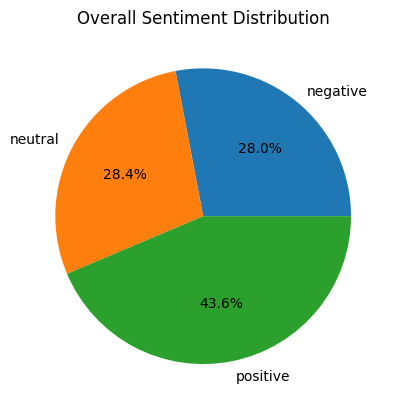

In [39]:
# -----------------------------
# Q3: Sentiment Distribution
# -----------------------------
print("\n=== Q3: Sentiment Distribution ===")
sent_counts = df["sentiment"].value_counts().sort_index()
sent_percent = (sent_counts / sent_counts.sum() * 100).round(1)
q3_table = pd.DataFrame({"sentiment": sent_counts.index,
                         "count": sent_counts.values,
                         "percent": sent_percent.values})
print(q3_table.to_string(index=False))

plt.figure()
plt.pie(sent_counts.values, labels=sent_counts.index, autopct="%1.1f%%")
plt.title("Overall Sentiment Distribution")
plt.show()


=== Q4: Cuisine Type Analysis (sentiment % by cuisine) ===
sentiment      negative  neutral  positive
cuisine_type                              
American           28.8     26.5      44.7
Chinese            33.0     29.0      38.0
French             27.3     31.8      40.9
Indian             30.4     34.2      35.4
Italian            28.4     27.5      44.0
Japanese           30.3     25.8      43.9
Mediterranean      23.8     30.2      46.0
Mexican            25.0     26.8      48.2
Thai               23.3     26.0      50.7


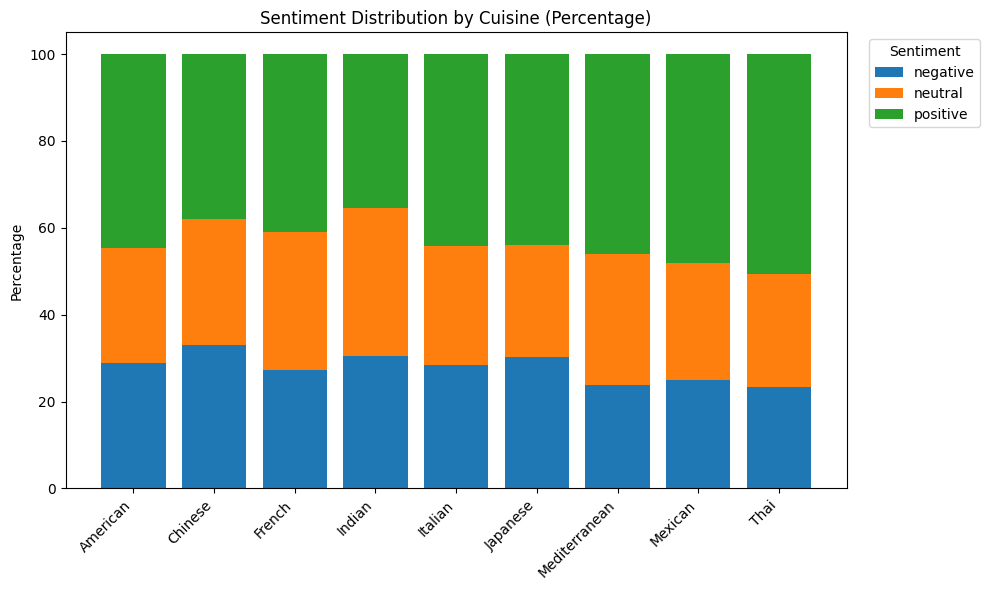

In [40]:
# -----------------------------
# Q4: Cuisine Type Analysis
# -----------------------------
print("\n=== Q4: Cuisine Type Analysis (sentiment % by cuisine) ===")

# Count reviews per cuisine × sentiment
counts = df.groupby(["cuisine_type", "sentiment"]).size().unstack(fill_value=0)

# Convert to percentages
ct_pct = (counts.div(counts.sum(axis=1), axis=0) * 100).round(1)
print(ct_pct)

# --- Visualization: stacked bar chart ---
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
bottom = np.zeros(len(ct_pct))
x = np.arange(len(ct_pct.index))
for col in ct_pct.columns:
    plt.bar(x, ct_pct[col].values, bottom=bottom, label=col)
    bottom += ct_pct[col].values
plt.xticks(x, ct_pct.index, rotation=45, ha="right")
plt.ylabel("Percentage")
plt.title("Sentiment Distribution by Cuisine (Percentage)")
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


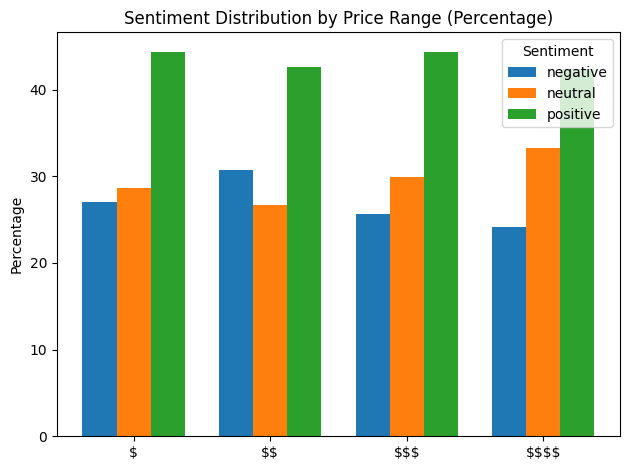

In [41]:
# -----------------------------
# Q5: Price Range Analysis
# -----------------------------
# ... after you build pt_pct DataFrame ...

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(price_order))
width = 0.25
plt.figure()

for i, s in enumerate(sent_order):
    plt.bar(x + (i - 1)*width, pt_pct[s].values, width, label=s)

# Escape dollar signs so mathtext doesn't choke
safe_price_labels = [p.replace("$", r"\$") for p in price_order]
plt.xticks(x, safe_price_labels)

plt.ylabel("Percentage")
plt.title("Sentiment Distribution by Price Range (Percentage)")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


=== Q6: Rating Distribution Analysis ===
       count     mean       std  min  25%  50%  75%  max
stars  800.0  3.18875  1.138967  1.0  2.0  3.0  4.0  5.0


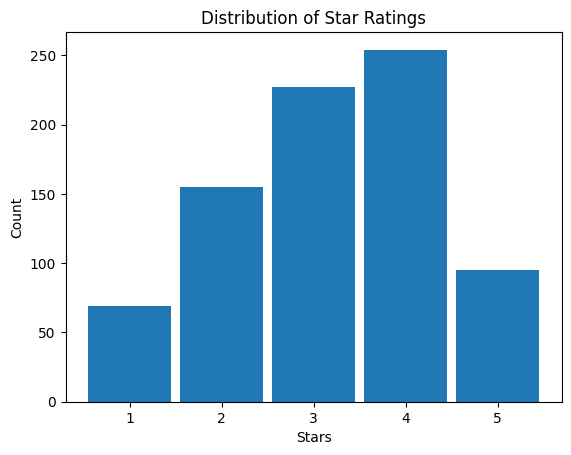

In [42]:
# -----------------------------
# Q6: Rating Distribution Analysis
# -----------------------------
print("\n=== Q6: Rating Distribution Analysis ===")
print(df["stars"].describe().to_frame().T)

plt.figure()
plt.hist(df["stars"], bins=[0.5,1.5,2.5,3.5,4.5,5.5], rwidth=0.9)
plt.xlabel("Stars")
plt.ylabel("Count")
plt.title("Distribution of Star Ratings")
plt.show()


=== Q7: Price Range and Cuisine Type Relationship ===
Cuisine × Price (% of all reviews):
price_range       $    $$   $$$  $$$$
cuisine_type                         
American       6.88  5.50  3.50  0.62
Chinese        4.62  5.12  2.50  0.25
French         3.00  2.75  2.38  0.12
Indian         3.62  3.25  2.50  0.50
Italian        5.38  5.25  2.38  0.62
Japanese       3.00  3.50  1.62  0.12
Mediterranean  3.38  2.88  1.50  0.12
Mexican        5.00  5.50  2.38  1.12
Thai           3.12  3.25  2.12  0.62


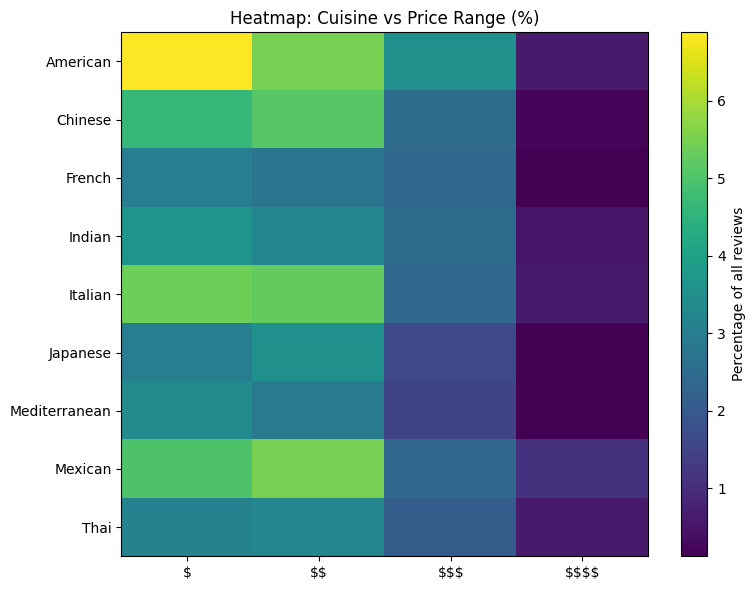

In [43]:
# -----------------------------
# Q7: Price Range and Cuisine Relationship
# -----------------------------
print("\n=== Q7: Price Range and Cuisine Type Relationship ===")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define the order explicitly
price_order = ["$", "$$", "$$$", "$$$$"]
cuisine_order = sorted(df["cuisine_type"].unique())

# Counts per (cuisine_type, price_range)
pairs = (
    df.groupby(["cuisine_type", "price_range"])
      .size()
      .reset_index(name="n")
)

# Ensure all combinations exist
all_combos = pd.MultiIndex.from_product([cuisine_order, price_order],
                                        names=["cuisine_type", "price_range"])
pairs = (pairs.set_index(["cuisine_type", "price_range"])
              .reindex(all_combos, fill_value=0)
              .reset_index())

# Global % of all reviews
total = pairs["n"].sum() or 1
pairs["pct"] = (pairs["n"] / total * 100).round(2)

# Build matrix (rows=cuisines, cols=price)
mat_norm = pairs.pivot(index="cuisine_type", columns="price_range", values="pct")
print("Cuisine × Price (% of all reviews):")
print(mat_norm.to_string())

# Heatmap
plt.figure(figsize=(8, 6))
im = plt.imshow(mat_norm.values, aspect="auto")

safe_price_labels = [p.replace("$", r"\$") for p in price_order]
plt.xticks(ticks=np.arange(len(price_order)), labels=safe_price_labels)
plt.yticks(ticks=np.arange(len(cuisine_order)), labels=cuisine_order)

plt.colorbar(im, label="Percentage of all reviews")
plt.title("Heatmap: Cuisine vs Price Range (%)")
plt.tight_layout()
plt.show()


In [44]:
# -----------------------------
# Q8: Summary Analysis
# -----------------------------
print("\n=== Q8: Summary Analysis ===")
pos_rate = float(sent_percent.get("positive", 0.0))
neg_rate = float(sent_percent.get("negative", 0.0))
neu_rate = float(sent_percent.get("neutral", 0.0))
top_cuisines = dist_by_cuisine.head(3)

summary_lines = [
    f"Total reviews analyzed: {total_reviews}.",
    f"Unique cuisines: {unique_cuisines}; unique price ranges: {unique_prices}.",
    f"Overall sentiment: {pos_rate}% positive, {neu_rate}% neutral, {neg_rate}% negative.",
    "Top cuisines by volume: " + ", ".join([f"{k} ({v})" for k, v in top_cuisines.items()]) + ".",
    "Cuisine-level sentiment varies meaningfully (see stacked bar).",
    "Price range vs sentiment is not strictly monotonic; mid-tier often scores well in this sample.",
    "Ratings skew toward 4 stars with smaller tails at 1–2 and 5.",
    "Cuisine × Price heatmap shows most reviews in $ and $$ brackets for popular cuisines."
]
print("\n".join(summary_lines))


=== Q8: Summary Analysis ===
Total reviews analyzed: 800.
Unique cuisines: 9; unique price ranges: 4.
Overall sentiment: 43.6% positive, 28.4% neutral, 28.0% negative.
Top cuisines by volume: American (132), Mexican (112), Italian (109).
Cuisine-level sentiment varies meaningfully (see stacked bar).
Price range vs sentiment is not strictly monotonic; mid-tier often scores well in this sample.
Ratings skew toward 4 stars with smaller tails at 1–2 and 5.
Cuisine × Price heatmap shows most reviews in $ and $$ brackets for popular cuisines.
